# **Car Price Prediction**

## **Importing Libraries and Reading Data**

In [681]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [682]:
df = pd.read_csv ('/content/drive/MyDrive/Datasets/quikr_car.csv')
df.head ()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [683]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        892 non-null    object
 1   company     892 non-null    object
 2   year        892 non-null    object
 3   Price       892 non-null    object
 4   kms_driven  840 non-null    object
 5   fuel_type   837 non-null    object
dtypes: object(6)
memory usage: 41.9+ KB


In [684]:
df.isnull().sum()

,0
name,0
company,0
year,0
Price,0
kms_driven,52
fuel_type,55


In [685]:
df['Price'] = df['Price'].astype(str).str.replace(',', '', regex=False)
df['Price'] = df['Price'].str.replace('₹', '', regex=False)
df['Price'] = df['Price'].str.replace('Ask For Price', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [686]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        892 non-null    object 
 1   company     892 non-null    object 
 2   year        892 non-null    object 
 3   Price       857 non-null    float64
 4   kms_driven  840 non-null    object 
 5   fuel_type   837 non-null    object 
dtypes: float64(1), object(5)
memory usage: 41.9+ KB


In [687]:
df['kms_driven'] = df['kms_driven'].astype(str).str.replace(',', '', regex=False)
df['kms_driven'] = df['kms_driven'].str.replace(' kms', '', regex=False)
df['kms_driven'] = pd.to_numeric(df['kms_driven'], errors='coerce')

In [688]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        892 non-null    object 
 1   company     892 non-null    object 
 2   year        892 non-null    object 
 3   Price       857 non-null    float64
 4   kms_driven  838 non-null    float64
 5   fuel_type   837 non-null    object 
dtypes: float64(2), object(4)
memory usage: 41.9+ KB


In [689]:
df.head ()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,80000.0,45000.0,Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,425000.0,40.0,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,NaN,22000.0,Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,325000.0,28000.0,Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,575000.0,36000.0,Diesel


In [690]:
df['year'] = pd.to_numeric (df['year'], errors='coerce')

In [691]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        892 non-null    object 
 1   company     892 non-null    object 
 2   year        842 non-null    float64
 3   Price       857 non-null    float64
 4   kms_driven  838 non-null    float64
 5   fuel_type   837 non-null    object 
dtypes: float64(3), object(3)
memory usage: 41.9+ KB


In [692]:
df.isnull().sum()

,0
name,0
company,0
year,50
Price,35
kms_driven,54
fuel_type,55


In [693]:
df.duplicated().sum()

np.int64(94)

In [694]:
df.drop_duplicates(inplace = True)

In [695]:
df['name'].duplicated().sum()

np.int64(273)

In [696]:
df[df['year'].isnull()]

,name,company,year,Price,kms_driven,fuel_type
185,"Commercial , DZire LDI, 2016, for sale",Commercial,NaN,NaN,NaN,NaN
195,"Tata indigo ecs LX, 201",Tata,NaN,150000.0,NaN,NaN
206,MARUTI SUZUKI DESI,MARUTI,NaN,400000.0,NaN,NaN
294,Yama,Yamaha,NaN,55000.0,NaN,NaN
360,selling car Ta,selling,NaN,NaN,NaN,NaN
368,Tata Zest 90,Tata,NaN,NaN,NaN,NaN
385,Maruti Suzuki Swift Dzire car,Maruti,NaN,300000.0,NaN,NaN
395,Maruti Suzuki Swift Dzire Tour (Gat,Maruti,NaN,300000.0,NaN,NaN
401,URJE,URJENT,NaN,180000.0,NaN,NaN
414,Swift Dzire Tour 27 Dec 2016 Regis,Swift,NaN,370000.0,NaN,NaN


Names and Company names are not right

## **DATA CLEANING**

In [697]:
df['company'].unique()

array(['Hyundai', 'Mahindra', 'Maruti', 'Ford', 'Skoda', 'Audi', 'Toyota',
       'Renault', 'Honda', 'Datsun', 'Mitsubishi', 'Tata', 'Volkswagen',
       'I', 'Chevrolet', 'Mini', 'BMW', 'Nissan', 'Hindustan', 'Fiat',
       'Commercial', 'MARUTI', 'Force', 'Mercedes', 'Land', 'Yamaha',
       'selling', 'URJENT', 'Swift', 'Used', 'Jaguar', 'Jeep', 'tata',
       'Sale', 'very', 'Volvo', 'i', '2012', 'Well', 'all', '7', '9',
       'scratch', 'urgent', 'sell', 'TATA', 'Any', 'Tara'], dtype=object)

In [698]:
df.loc[df['company'] == 'tata', 'company'] = df.loc[df['company'] == 'tata', 'company'].str.replace('tata' , 'TATA')

In [699]:
df.loc[df['company'] == 'Tara', 'company'] = df.loc[df['company'] == 'Tara', 'company'].str.replace('Tara' , 'TATA')

In [700]:
df.loc[df['company'] == 'Tata', 'company'] = df.loc[df['company'] == 'Tata', 'company'].str.replace('Tata' , 'TATA')

In [701]:
df.loc[df['company'] == 'MARUTI', 'company'] = df.loc[df['company'] == 'MARUTI', 'company'].str.replace('MARUTI' , 'Maruti')

In [702]:
mask = (df['company'] == 'selling') | (df['company'] == 'sell')
df.loc[mask, 'company'] = 'Sale'

In [703]:
df['company'].unique()

array(['Hyundai', 'Mahindra', 'Maruti', 'Ford', 'Skoda', 'Audi', 'Toyota',
       'Renault', 'Honda', 'Datsun', 'Mitsubishi', 'TATA', 'Volkswagen',
       'I', 'Chevrolet', 'Mini', 'BMW', 'Nissan', 'Hindustan', 'Fiat',
       'Commercial', 'Force', 'Mercedes', 'Land', 'Yamaha', 'Sale',
       'URJENT', 'Swift', 'Used', 'Jaguar', 'Jeep', 'very', 'Volvo', 'i',
       '2012', 'Well', 'all', '7', '9', 'scratch', 'urgent', 'Any'],
      dtype=object)

Many company names are still not right.

In [704]:
df[df['company'] == 'Sale']

,name,company,year,Price,kms_driven,fuel_type
360,selling car Ta,Sale,NaN,NaN,NaN,NaN
616,Sale tata,Sale,NaN,100000.0,NaN,NaN
645,Sale Hyundai xcent commerc,Sale,NaN,NaN,NaN,NaN
805,sell my car Maruti Suzuki Swif,Sale,NaN,300000.0,NaN,NaN


In [705]:
df.loc[df['name'] == 'Sale tata', 'company'] = 'TATA'

In [706]:
df.loc[df['name'] == 'selling car Ta', 'company'] = 'TATA'

In [707]:
df.loc[df['name'] == 'Sale Hyundai xcent commerc', 'company'] = 'Hyundai'

In [708]:
df.loc[df['name'] == 'sell my car Maruti Suzuki Swif', 'company'] = 'Maruti'

In [709]:
df[df['company'] == 'Sale']

,name,company,year,Price,kms_driven,fuel_type


In [710]:
df[df['company'] == 'URJENT']

,name,company,year,Price,kms_driven,fuel_type
401,URJE,URJENT,NaN,180000.0,NaN,NaN


This is garbage data with noise

In [711]:
df = df[df['company'] != 'URJENT']
df['company'].unique()

array(['Hyundai', 'Mahindra', 'Maruti', 'Ford', 'Skoda', 'Audi', 'Toyota',
       'Renault', 'Honda', 'Datsun', 'Mitsubishi', 'TATA', 'Volkswagen',
       'I', 'Chevrolet', 'Mini', 'BMW', 'Nissan', 'Hindustan', 'Fiat',
       'Commercial', 'Force', 'Mercedes', 'Land', 'Yamaha', 'Swift',
       'Used', 'Jaguar', 'Jeep', 'very', 'Volvo', 'i', '2012', 'Well',
       'all', '7', '9', 'scratch', 'urgent', 'Any'], dtype=object)

In [712]:
df[df['company'] == 'urgent']

,name,company,year,Price,kms_driven,fuel_type
803,urgent sell my Mahindra qu,urgent,NaN,350000.0,NaN,NaN
809,urgent sale Ta,urgent,NaN,220000.0,NaN,NaN


In [713]:
df.loc[df['name'] == 'urgent sell my Mahindra qu', 'company'] = 'Mahindra'
df.loc[df['name'] == 'urgent sale Ta', 'company'] = 'TATA'

In [714]:
df[df['company'] == 'Used']

,name,company,year,Price,kms_driven,fuel_type
441,Used Commercial Maruti Omn,Used,NaN,150000.0,NaN,NaN
614,Used bt new conditions ta,Used,NaN,255000.0,NaN,NaN


In [715]:
df.loc[df['name'] == 'Used Commercial Maruti Omn', 'company'] = 'Maruti'

In [716]:
df.loc[df['name'] == 'Used bt new conditions ta', 'company'] = 'TATA'

In [717]:
df[(df['company'] == 'I') | (df['company'] == 'i')]

,name,company,year,Price,kms_driven,fuel_type
69,I want to sell my car Tata Zest,I,2017.0,NaN,NaN,NaN
723,I want to sell my commercial car due t,I,NaN,475000.0,NaN,NaN
725,i want sale my car.no emi....uber atta,i,NaN,320000.0,NaN,NaN


In [718]:
df.loc[df['name'] == 'I want to sell my car Tata Zest', 'company'] = 'TATA'

In [719]:
df[(df['company'] == 'I') | (df['company'] == 'i')]

,name,company,year,Price,kms_driven,fuel_type
723,I want to sell my commercial car due t,I,NaN,475000.0,NaN,NaN
725,i want sale my car.no emi....uber atta,i,NaN,320000.0,NaN,NaN


These two are noisy

In [720]:
df = df[df['name'] != 'I want to sell my commercial car due t']
df['company'].unique()

array(['Hyundai', 'Mahindra', 'Maruti', 'Ford', 'Skoda', 'Audi', 'Toyota',
       'Renault', 'Honda', 'Datsun', 'Mitsubishi', 'TATA', 'Volkswagen',
       'Chevrolet', 'Mini', 'BMW', 'Nissan', 'Hindustan', 'Fiat',
       'Commercial', 'Force', 'Mercedes', 'Land', 'Yamaha', 'Swift',
       'Jaguar', 'Jeep', 'very', 'Volvo', 'i', '2012', 'Well', 'all', '7',
       '9', 'scratch', 'Any'], dtype=object)

In [721]:
df = df[df['name'] != 'i want sale my car.no emi....uber atta']
df['company'].unique()

array(['Hyundai', 'Mahindra', 'Maruti', 'Ford', 'Skoda', 'Audi', 'Toyota',
       'Renault', 'Honda', 'Datsun', 'Mitsubishi', 'TATA', 'Volkswagen',
       'Chevrolet', 'Mini', 'BMW', 'Nissan', 'Hindustan', 'Fiat',
       'Commercial', 'Force', 'Mercedes', 'Land', 'Yamaha', 'Swift',
       'Jaguar', 'Jeep', 'very', 'Volvo', '2012', 'Well', 'all', '7', '9',
       'scratch', 'Any'], dtype=object)

In [722]:
df[(df['company'] == 'all') | (df['company'] == 'Any')]

,name,company,year,Price,kms_driven,fuel_type
796,all paper updated tata indica v2 and u,all,NaN,145000.0,NaN,NaN
845,Any type car avaiabel hare...comercica,Any,NaN,170000.0,NaN,NaN


In [723]:
df.loc[df['name'] == 'all paper updated tata indica v2 and u', 'company'] = 'TATA'

In [724]:
df = df[df['name'] != 'Any type car avaiabel hare...comercica']

In [725]:
df[(df['company'] == 'very') | (df['company'] == 'Well')]

,name,company,year,Price,kms_driven,fuel_type
643,very good condition tata bolts are av,very,NaN,200000.0,NaN,NaN
795,Well mentained Tata Sumo,Well,NaN,380000.0,NaN,NaN


In [726]:
df.loc[df['name'] == 'very good condition tata bolts are av', 'company'] = 'TATA'
df.loc[df['name'] == 'Well mentained Tata Sumo', 'company'] = 'TATA'

In [727]:
df['company'].unique()

array(['Hyundai', 'Mahindra', 'Maruti', 'Ford', 'Skoda', 'Audi', 'Toyota',
       'Renault', 'Honda', 'Datsun', 'Mitsubishi', 'TATA', 'Volkswagen',
       'Chevrolet', 'Mini', 'BMW', 'Nissan', 'Hindustan', 'Fiat',
       'Commercial', 'Force', 'Mercedes', 'Land', 'Yamaha', 'Swift',
       'Jaguar', 'Jeep', 'Volvo', '2012', '7', '9', 'scratch'],
      dtype=object)

In [728]:
df[(df['company'] == '7') | (df['company'] == '9') | (df['company'] == '2012')]

,name,company,year,Price,kms_driven,fuel_type
792,2012 Tata Sumo Gold f,2012,NaN,250000.0,NaN,NaN
798,7 SEATER MAHINDRA BOLERO IN VERY GOOD,7,NaN,NaN,NaN,NaN
799,9 SEATER MAHINDRA BOL,9,NaN,NaN,NaN,NaN


In [729]:
df.loc[df['name'] == '2012 Tata Sumo Gold f', 'company'] = 'TATA'
df.loc[df['name'] == '7 SEATER MAHINDRA BOLERO IN VERY GOOD', 'company'] = 'Mahindra'
df.loc[df['name'] == '9 SEATER MAHINDRA BOL', 'company'] = 'Mahindra'

In [730]:
df['company'].unique()

array(['Hyundai', 'Mahindra', 'Maruti', 'Ford', 'Skoda', 'Audi', 'Toyota',
       'Renault', 'Honda', 'Datsun', 'Mitsubishi', 'TATA', 'Volkswagen',
       'Chevrolet', 'Mini', 'BMW', 'Nissan', 'Hindustan', 'Fiat',
       'Commercial', 'Force', 'Mercedes', 'Land', 'Yamaha', 'Swift',
       'Jaguar', 'Jeep', 'Volvo', 'scratch'], dtype=object)

In [731]:
df[df['company'] == 'scratch']

,name,company,year,Price,kms_driven,fuel_type
800,scratch less Tata I,scratch,NaN,140000.0,NaN,NaN


In [732]:
df.loc[df['name'] == 'scratch less Tata I', 'company'] = 'TATA'

In [733]:
df[df['company'] == 'Land']

,name,company,year,Price,kms_driven,fuel_type
232,Land Rover Freelander 2 SE,Land,2015.0,2100000.0,30000.0,Diesel


In [734]:
df.loc[df['name'] == 'Land Rover Freelander 2 SE', 'company'] = 'Land Rover'

In [735]:
df['company'].unique()

array(['Hyundai', 'Mahindra', 'Maruti', 'Ford', 'Skoda', 'Audi', 'Toyota',
       'Renault', 'Honda', 'Datsun', 'Mitsubishi', 'TATA', 'Volkswagen',
       'Chevrolet', 'Mini', 'BMW', 'Nissan', 'Hindustan', 'Fiat',
       'Commercial', 'Force', 'Mercedes', 'Land Rover', 'Yamaha', 'Swift',
       'Jaguar', 'Jeep', 'Volvo'], dtype=object)

In [736]:
df[df['company'] == 'Commercial']

,name,company,year,Price,kms_driven,fuel_type
185,"Commercial , DZire LDI, 2016, for sale",Commercial,NaN,NaN,NaN,NaN
593,Commercial Chevrolet Sail Hatchback ca,Commercial,NaN,225000.0,NaN,NaN
599,Commercial Car Ta,Commercial,NaN,371500.0,NaN,NaN
802,Commercial Chevrolet beat for sale in,Commercial,NaN,180000.0,NaN,NaN
808,Commercial Maruti Suzuki Alto Lxi 800,Commercial,NaN,NaN,NaN,NaN


In [737]:
df.loc[df['name'] == 'Commercial Chevrolet Sail Hatchback ca', 'company'] = 'Chevrolet'
df.loc[df['name'] == 'Commercial Maruti Suzuki Alto Lxi 800', 'company'] = 'Maruti'

df['company'].unique()

array(['Hyundai', 'Mahindra', 'Maruti', 'Ford', 'Skoda', 'Audi', 'Toyota',
       'Renault', 'Honda', 'Datsun', 'Mitsubishi', 'TATA', 'Volkswagen',
       'Chevrolet', 'Mini', 'BMW', 'Nissan', 'Hindustan', 'Fiat',
       'Commercial', 'Force', 'Mercedes', 'Land Rover', 'Yamaha', 'Swift',
       'Jaguar', 'Jeep', 'Volvo'], dtype=object)

In [738]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 794 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        794 non-null    object 
 1   company     794 non-null    object 
 2   year        749 non-null    float64
 3   Price       761 non-null    float64
 4   kms_driven  746 non-null    float64
 5   fuel_type   745 non-null    object 
dtypes: float64(3), object(3)
memory usage: 43.4+ KB


In [739]:
df.loc[df['name'] == 'Swift Dzire Tour 27 Dec 2016 Regis', 'company'] = 'Maruti'

Company is clean now. But model names are still messy.

In [740]:
df['name_clean'] = df.apply (lambda row: row['name'].replace (row['company'] , '').strip () if pd.notnull (row['company']) else row['name'], axis=1)

In [741]:
df

,name,company,year,Price,kms_driven,fuel_type,name_clean
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007.0,80000.0,45000.0,Petrol,Santro Xing XO eRLX Euro III
1,Mahindra Jeep CL550 MDI,Mahindra,2006.0,425000.0,40.0,Diesel,Jeep CL550 MDI
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018.0,NaN,22000.0,Petrol,Suzuki Alto 800 Vxi
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014.0,325000.0,28000.0,Petrol,Grand i10 Magna 1.2 Kappa VTVT
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014.0,575000.0,36000.0,Diesel,EcoSport Titanium 1.5L TDCi
...,...,...,...,...,...,...,...
887,Ta,TATA,NaN,310000.0,NaN,NaN,Ta
888,Tata Zest XM Diesel,TATA,2018.0,260000.0,27000.0,Diesel,Tata Zest XM Diesel
889,Mahindra Quanto C8,Mahindra,2013.0,390000.0,40000.0,Diesel,Quanto C8
890,Honda Amaze 1.2 E i VTEC,Honda,2014.0,180000.0,NaN,NaN,Amaze 1.2 E i VTEC


In [742]:
df.shape

(794, 7)

In [743]:
bad_patterns = r'want|sell|sale|urgent|good|condition|car|vehicle|new|old'

mask = df['name_clean'].str.contains(bad_patterns, case=False, na=False)

df = df[~mask]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 763 entries, 0 to 891
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        763 non-null    object 
 1   company     763 non-null    object 
 2   year        736 non-null    float64
 3   Price       735 non-null    float64
 4   kms_driven  734 non-null    float64
 5   fuel_type   733 non-null    object 
 6   name_clean  763 non-null    object 
dtypes: float64(3), object(4)
memory usage: 47.7+ KB


In [744]:
df

,name,company,year,Price,kms_driven,fuel_type,name_clean
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007.0,80000.0,45000.0,Petrol,Santro Xing XO eRLX Euro III
1,Mahindra Jeep CL550 MDI,Mahindra,2006.0,425000.0,40.0,Diesel,Jeep CL550 MDI
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018.0,NaN,22000.0,Petrol,Suzuki Alto 800 Vxi
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014.0,325000.0,28000.0,Petrol,Grand i10 Magna 1.2 Kappa VTVT
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014.0,575000.0,36000.0,Diesel,EcoSport Titanium 1.5L TDCi
...,...,...,...,...,...,...,...
887,Ta,TATA,NaN,310000.0,NaN,NaN,Ta
888,Tata Zest XM Diesel,TATA,2018.0,260000.0,27000.0,Diesel,Tata Zest XM Diesel
889,Mahindra Quanto C8,Mahindra,2013.0,390000.0,40000.0,Diesel,Quanto C8
890,Honda Amaze 1.2 E i VTEC,Honda,2014.0,180000.0,NaN,NaN,Amaze 1.2 E i VTEC


## **FILLING MISSING DATA**

In [745]:
df['Price'] = df.groupby('name_clean')['Price'].transform(lambda x: x.fillna(x.median()))

In [746]:
df.isnull().sum()

,0
name,0
company,0
year,27
Price,17
kms_driven,29
fuel_type,30
name_clean,0


In [747]:
df1 = df.copy ()

In [748]:
df['Price'] = df['Price'].fillna (df.groupby (['company' , 'year'])['Price'].transform('median'))

df.isnull().sum()

,0
name,0
company,0
year,27
Price,8
kms_driven,29
fuel_type,30
name_clean,0


In [749]:
df['Price'] = df['Price'].fillna (df.groupby (['company'])['Price'].transform('median'))

df.isnull().sum()

,0
name,0
company,0
year,27
Price,0
kms_driven,29
fuel_type,30
name_clean,0


In [750]:
df['year'] = df['year'].fillna(df.groupby(['company'])['year'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

In [751]:
df.isnull().sum()

,0
name,0
company,0
year,1
Price,0
kms_driven,29
fuel_type,30
name_clean,0


In [752]:
df['kms_driven'] = df['kms_driven'].fillna (df.groupby (['company'])['kms_driven'].transform('median'))

df.isnull().sum()

,0
name,0
company,0
year,1
Price,0
kms_driven,1
fuel_type,30
name_clean,0


In [753]:
df['fuel_type'] = df.groupby('name_clean')['fuel_type'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))

df.isnull().sum()

,0
name,0
company,0
year,1
Price,0
kms_driven,1
fuel_type,29
name_clean,0


In [754]:
df['fuel_type'] = df.groupby('company')['fuel_type'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))

df.isnull().sum()

,0
name,0
company,0
year,1
Price,0
kms_driven,1
fuel_type,1
name_clean,0


In [755]:
df[df['fuel_type'].isnull()]

,name,company,year,Price,kms_driven,fuel_type,name_clean
294,Yama,Yamaha,NaN,55000.0,NaN,NaN,Yama


In [756]:
df1 = df.dropna()

df1.isnull().sum()

,0
name,0
company,0
year,0
Price,0
kms_driven,0
fuel_type,0
name_clean,0


In [757]:
df1

,name,company,year,Price,kms_driven,fuel_type,name_clean
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007.0,80000.0,45000.0,Petrol,Santro Xing XO eRLX Euro III
1,Mahindra Jeep CL550 MDI,Mahindra,2006.0,425000.0,40.0,Diesel,Jeep CL550 MDI
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018.0,220000.0,22000.0,Petrol,Suzuki Alto 800 Vxi
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014.0,325000.0,28000.0,Petrol,Grand i10 Magna 1.2 Kappa VTVT
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014.0,575000.0,36000.0,Diesel,EcoSport Titanium 1.5L TDCi
...,...,...,...,...,...,...,...
887,Ta,TATA,2016.0,310000.0,70000.0,Diesel,Ta
888,Tata Zest XM Diesel,TATA,2018.0,260000.0,27000.0,Diesel,Tata Zest XM Diesel
889,Mahindra Quanto C8,Mahindra,2013.0,390000.0,40000.0,Diesel,Quanto C8
890,Honda Amaze 1.2 E i VTEC,Honda,2014.0,180000.0,42000.0,Petrol,Amaze 1.2 E i VTEC


In [758]:
df1 = df1.drop(columns=['name'])
df1.head()

,company,year,Price,kms_driven,fuel_type,name_clean
0,Hyundai,2007.0,80000.0,45000.0,Petrol,Santro Xing XO eRLX Euro III
1,Mahindra,2006.0,425000.0,40.0,Diesel,Jeep CL550 MDI
2,Maruti,2018.0,220000.0,22000.0,Petrol,Suzuki Alto 800 Vxi
3,Hyundai,2014.0,325000.0,28000.0,Petrol,Grand i10 Magna 1.2 Kappa VTVT
4,Ford,2014.0,575000.0,36000.0,Diesel,EcoSport Titanium 1.5L TDCi


### **Dataset is clean now**

## **EDA**

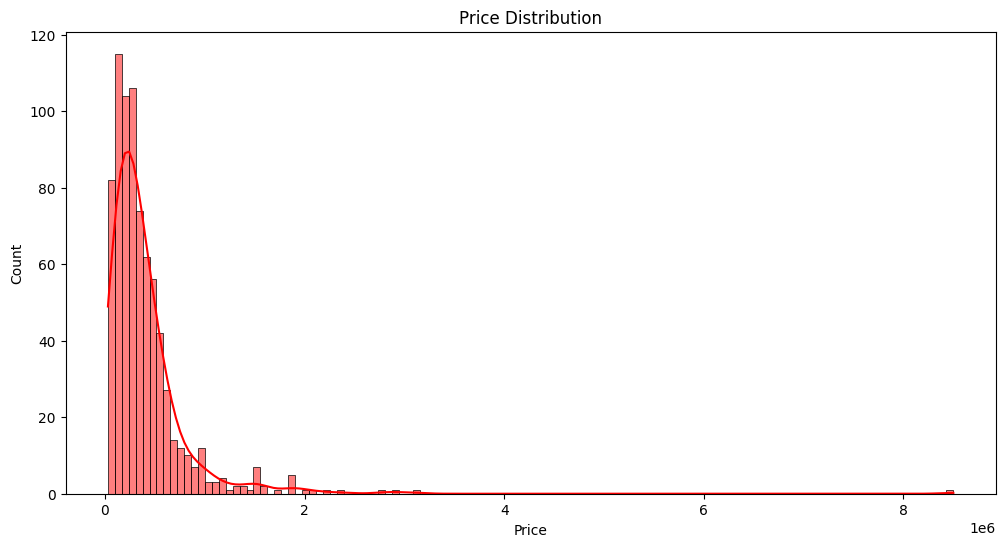

In [759]:
plt.figure (figsize = (12,6))
sns.histplot(df1['Price'], kde=True , color = 'red')
plt.title("Price Distribution")
plt.show()

- Right Skewed

- Extreme Imbalance

- Majority budget cars and minority luxury cars so model will bias towards budget cars

- Log transformation needed on price to deal with the skewness

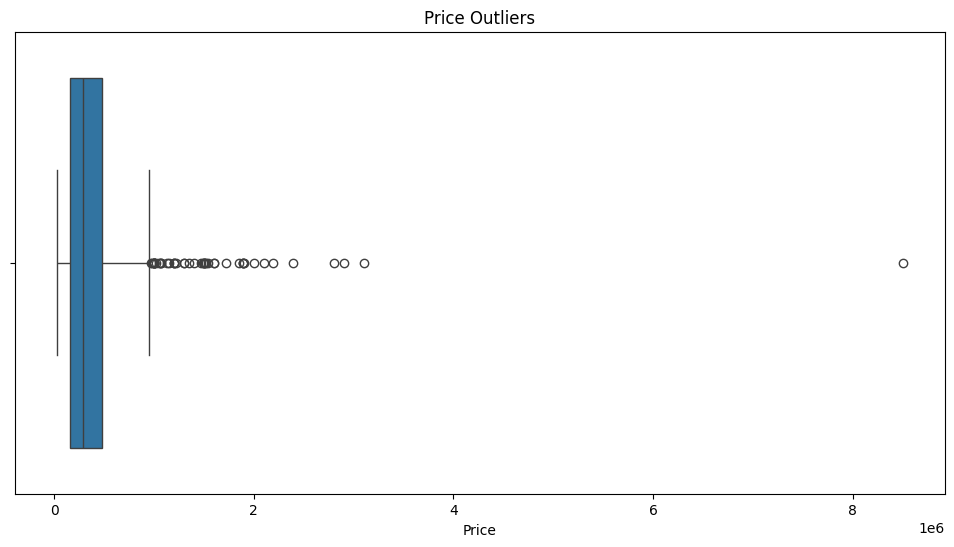

In [760]:
plt.figure (figsize = (12,6))
sns.boxplot(x=df1['Price'])
plt.title("Price Outliers")
plt.show()

Extreme Outliers

In [761]:
df1['log_price'] = np.log1p(df1['Price'])

df1.head()

,company,year,Price,kms_driven,fuel_type,name_clean,log_price
0,Hyundai,2007.0,80000.0,45000.0,Petrol,Santro Xing XO eRLX Euro III,11.289794
1,Mahindra,2006.0,425000.0,40.0,Diesel,Jeep CL550 MDI,12.959847
2,Maruti,2018.0,220000.0,22000.0,Petrol,Suzuki Alto 800 Vxi,12.301387
3,Hyundai,2014.0,325000.0,28000.0,Petrol,Grand i10 Magna 1.2 Kappa VTVT,12.691584
4,Ford,2014.0,575000.0,36000.0,Diesel,EcoSport Titanium 1.5L TDCi,13.262127


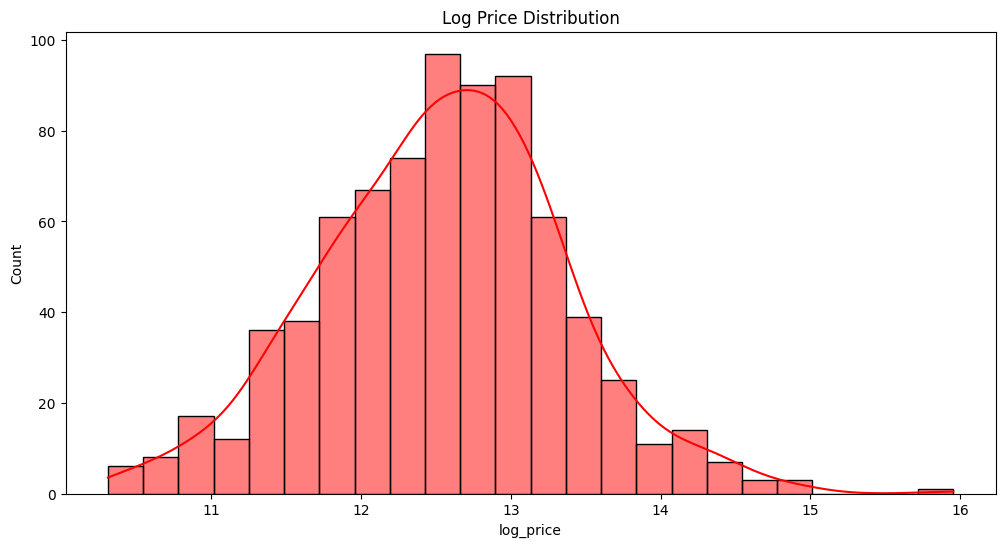

In [762]:
plt.figure (figsize = (12,6))
sns.histplot(df1['log_price'], kde=True , color = 'red')
plt.title("Log Price Distribution")
plt.show()

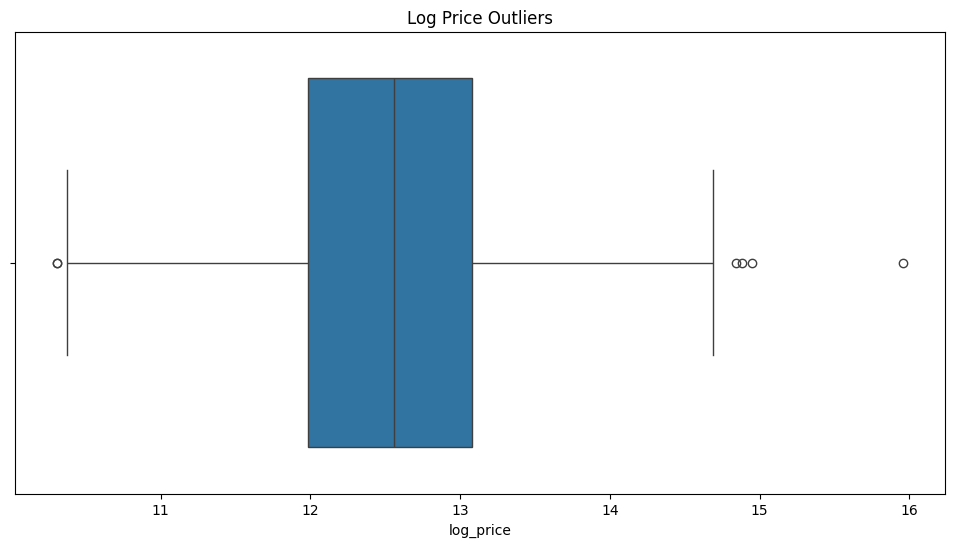

In [763]:
plt.figure (figsize = (12,6))
sns.boxplot(x=df1['log_price'])
plt.title("Log Price Outliers")
plt.show()

Variiation stabilized and outliers controlled

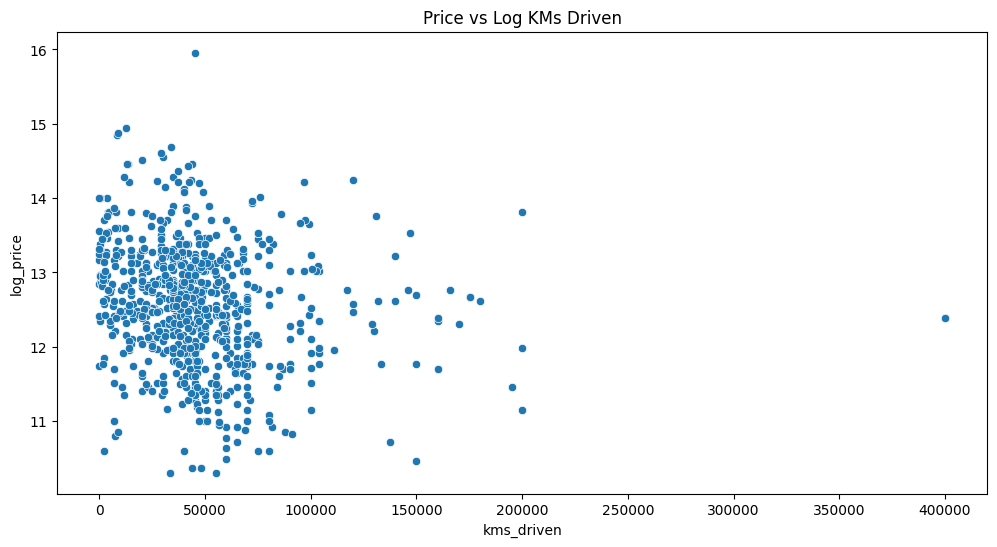

In [764]:
plt.figure (figsize = (12,6))
sns.scatterplot(x='kms_driven', y='log_price', data=df1)
plt.title("Price vs Log KMs Driven")
plt.show()

- Kms Driven increases price decreases

- Points are widely scattered

- Log transformation needed here as well

In [765]:
df1['log_kms_driven'] = np.log1p(df1['kms_driven'])

df1.head()

,company,year,Price,kms_driven,fuel_type,name_clean,log_price,log_kms_driven
0,Hyundai,2007.0,80000.0,45000.0,Petrol,Santro Xing XO eRLX Euro III,11.289794,10.714440
1,Mahindra,2006.0,425000.0,40.0,Diesel,Jeep CL550 MDI,12.959847,3.713572
2,Maruti,2018.0,220000.0,22000.0,Petrol,Suzuki Alto 800 Vxi,12.301387,9.998843
3,Hyundai,2014.0,325000.0,28000.0,Petrol,Grand i10 Magna 1.2 Kappa VTVT,12.691584,10.239996
4,Ford,2014.0,575000.0,36000.0,Diesel,EcoSport Titanium 1.5L TDCi,13.262127,10.491302


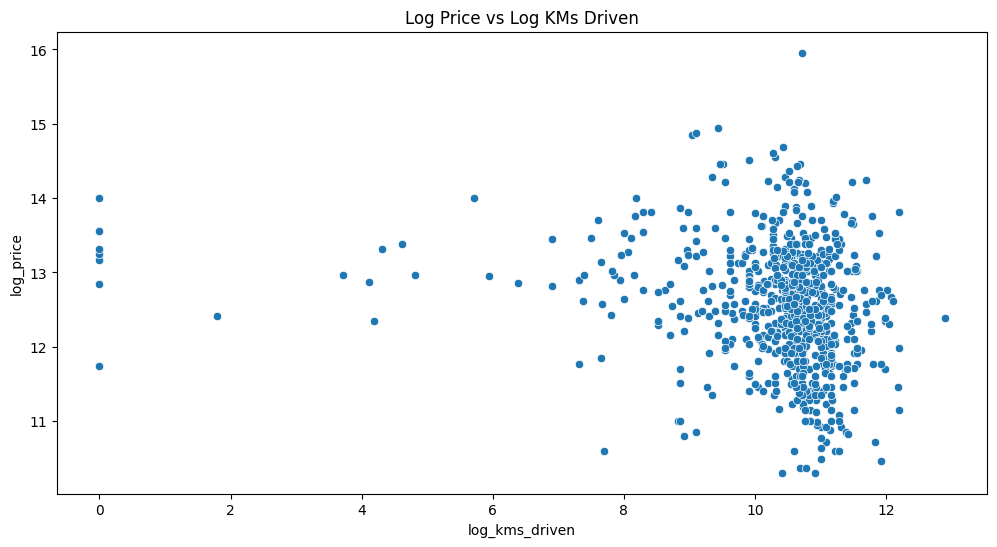

In [766]:
plt.figure (figsize = (12,6))
sns.scatterplot(x='log_kms_driven', y='log_price', data=df1)
plt.title("Log Price vs Log KMs Driven")
plt.show()

In [767]:
df1.head()

,company,year,Price,kms_driven,fuel_type,name_clean,log_price,log_kms_driven
0,Hyundai,2007.0,80000.0,45000.0,Petrol,Santro Xing XO eRLX Euro III,11.289794,10.714440
1,Mahindra,2006.0,425000.0,40.0,Diesel,Jeep CL550 MDI,12.959847,3.713572
2,Maruti,2018.0,220000.0,22000.0,Petrol,Suzuki Alto 800 Vxi,12.301387,9.998843
3,Hyundai,2014.0,325000.0,28000.0,Petrol,Grand i10 Magna 1.2 Kappa VTVT,12.691584,10.239996
4,Ford,2014.0,575000.0,36000.0,Diesel,EcoSport Titanium 1.5L TDCi,13.262127,10.491302


In [768]:
import datetime

current_year = datetime.datetime.now().year

df1['car_age'] = current_year - df1['year']

In [769]:
df2 = df1.drop (columns = ['year' , 'Price' , 'kms_driven'])
df2.head()

,company,fuel_type,name_clean,log_price,log_kms_driven,car_age
0,Hyundai,Petrol,Santro Xing XO eRLX Euro III,11.289794,10.714440,19.0
1,Mahindra,Diesel,Jeep CL550 MDI,12.959847,3.713572,20.0
2,Maruti,Petrol,Suzuki Alto 800 Vxi,12.301387,9.998843,8.0
3,Hyundai,Petrol,Grand i10 Magna 1.2 Kappa VTVT,12.691584,10.239996,12.0
4,Ford,Diesel,EcoSport Titanium 1.5L TDCi,13.262127,10.491302,12.0


In [770]:
df2['name_clean'].nunique()

494

In [771]:
df2['model'] = df2['name_clean'].str.split().str[:2].str.join(' ')

In [772]:
df2.head()

,company,fuel_type,name_clean,log_price,log_kms_driven,car_age,model
0,Hyundai,Petrol,Santro Xing XO eRLX Euro III,11.289794,10.714440,19.0,Santro Xing
1,Mahindra,Diesel,Jeep CL550 MDI,12.959847,3.713572,20.0,Jeep CL550
2,Maruti,Petrol,Suzuki Alto 800 Vxi,12.301387,9.998843,8.0,Suzuki Alto
3,Hyundai,Petrol,Grand i10 Magna 1.2 Kappa VTVT,12.691584,10.239996,12.0,Grand i10
4,Ford,Diesel,EcoSport Titanium 1.5L TDCi,13.262127,10.491302,12.0,EcoSport Titanium


In [773]:
df2 = df2.drop (columns = ['name_clean'])
df2.head()

,company,fuel_type,log_price,log_kms_driven,car_age,model
0,Hyundai,Petrol,11.289794,10.714440,19.0,Santro Xing
1,Mahindra,Diesel,12.959847,3.713572,20.0,Jeep CL550
2,Maruti,Petrol,12.301387,9.998843,8.0,Suzuki Alto
3,Hyundai,Petrol,12.691584,10.239996,12.0,Grand i10
4,Ford,Diesel,13.262127,10.491302,12.0,EcoSport Titanium


In [774]:
df2.isnull().sum()

,0
company,0
fuel_type,0
log_price,0
log_kms_driven,0
car_age,0
model,0


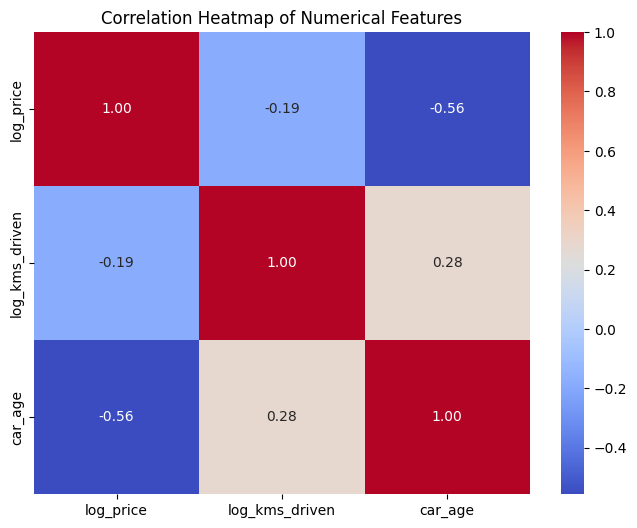

In [775]:
numerical_df = df2[['log_price', 'log_kms_driven', 'car_age']]
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

EDA and cleaning done

## **Model**

### **Feature and Target**

In [776]:
X = df2.drop(columns=['log_price'])
y = df2['log_price']

### **Identify Column Types**

In [777]:
categorical_cols = ['company', 'fuel_type', 'model']
numerical_cols = ['log_kms_driven', 'car_age']

### **Preprocessing Pipeline**

In [778]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

### **Defining Models and Hyperparameters**

In [779]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {
    'Linear': (LinearRegression(), {}),

    'Ridge': (
        Ridge(),
        {'model__alpha': [0.1, 1, 10, 50]}
    ),

    'Lasso': (
        Lasso(),
        {'model__alpha': [0.001, 0.01, 0.1, 1]}
    ),

    'RF': (
        RandomForestRegressor(random_state=42),
        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [None, 10, 20],
            'model__min_samples_split': [2, 5]
        }
    ),

    'XGB': (
        XGBRegressor(
            random_state=42,
            objective='reg:squarederror',
            verbosity=0
        ),
        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [3, 5, 7],
            'model__learning_rate': [0.05, 0.1],
            'model__subsample': [0.8, 1.0]
        }
    )
}

### **Cross Validation and Grid Search Loop**

In [780]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

results = {}

for name, (model, params) in models.items():

    print(f"\n🔍 Training {name}...")

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    grid = GridSearchCV(
        pipe,
        param_grid=params,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    grid.fit(X, y)

    results[name] = {
        'best_score': grid.best_score_,
        'best_params': grid.best_params_
    }

    print(f"Best R2: {grid.best_score_}")
    print(f"Best Params: {grid.best_params_}")


🔍 Training Linear...
Best R2: 0.7158004974393595
Best Params: {}

🔍 Training Ridge...
Best R2: 0.7227023969808231
Best Params: {'model__alpha': 1}

🔍 Training Lasso...
Best R2: 0.7017911998254686
Best Params: {'model__alpha': 0.001}

🔍 Training RF...
Best R2: 0.6201745090277881
Best Params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}

🔍 Training XGB...
Best R2: 0.6819442238601562
Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}


- Ridge Model came out on top with R2 = 0.72

- Linear Models Outperformed Tree Models

### **Testing**

Train Test Split

In [781]:
from sklearn.model_selection import train_test_split

X = df2.drop(columns=['log_price'])
y = df2['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [782]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

best_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1))
])

In [783]:
best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['log_kms_driven',
                                                   'car_age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['company', 'fuel_type',
                                                   'model'])])),
                ('model', Ridge(alpha=1))])

In [784]:
y_pred = best_model.predict(X_test)

In [785]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("Test R2:", r2_score(y_test, y_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Test R2: 0.7764881978089123
Test RMSE: 0.3832570552585281


- So our Ridge Model Explain 77.6% variations in car prices

- RMSE is not directly interpretable now

In [786]:
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

from sklearn.metrics import mean_squared_error
import numpy as np

print("Real RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_pred_actual)))

Real RMSE: 273431.9662426167


### **Trying Interaction Feature**

In [787]:
df2['age_km_interaction'] = df2['car_age'] * df2['log_kms_driven']

In [788]:
X = df2.drop(columns=['log_price'])
y = df2['log_price']

In [789]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [790]:
categorical_cols = ['company', 'fuel_type', 'model']
numerical_cols = ['log_kms_driven', 'car_age', 'age_km_interaction']

In [791]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [792]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

model1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1))
])

In [793]:
model1.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['log_kms_driven', 'car_age',
                                                   'age_km_interaction']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['company', 'fuel_type',
                                                   'model'])])),
                ('model', Ridge(alpha=1))])

In [794]:
y_pred = model1.predict(X_test)

In [795]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("Test R2:", r2_score(y_test, y_pred))
print("Test RMSE (log):", np.sqrt(mean_squared_error(y_test, y_pred)))

Test R2: 0.7701972841707081
Test RMSE (log): 0.38861316288565256


In [796]:
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

print("Real RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_pred_actual)))

Real RMSE: 274547.86404673633


## Comparing both:

- Without Interaction Feature:

    1. R2 = 0.7764 and RMSE = 273431

    2. R2 = 0.7702 and RMSE = 274547

I engineered an interaction feature between car age and kilometers driven to capture compound depreciation effects. However, cross-validation showed no improvement in R² or RMSE, indicating the existing features already explained the variance sufficiently.

In [796]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
coefficients = model.named_steps['model'].coef_

import pandas as pd
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': coefficients
}).sort_values(by='importance', ascending=False)

feat_imp.head(10)

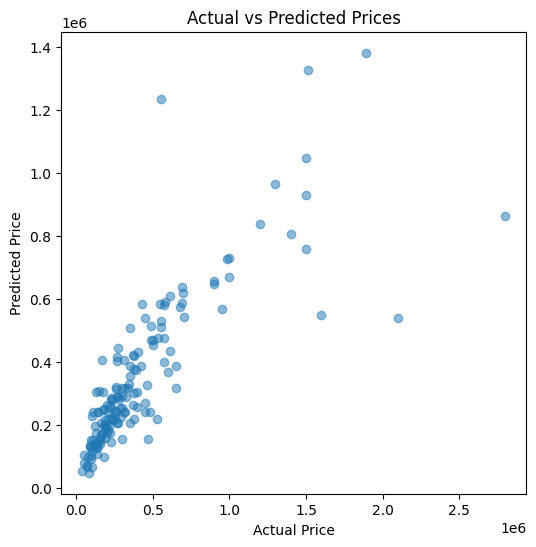

In [797]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

- Lower price range, points are fairly alligned

- Higher Price range are scattered

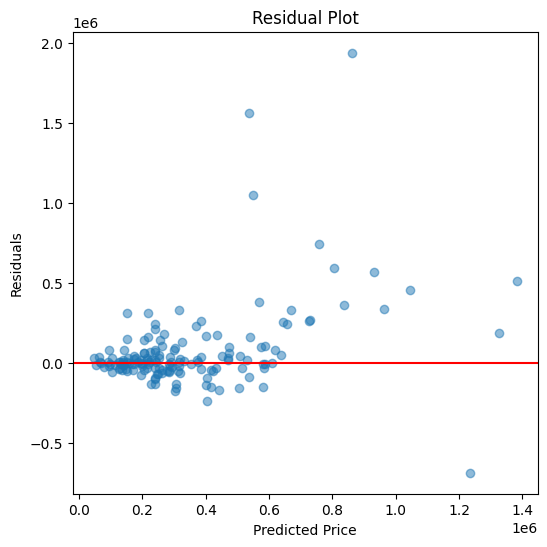

In [798]:
residuals = y_test_actual - y_pred_actual

plt.figure(figsize=(6,6))
plt.scatter(y_pred_actual, residuals, alpha=0.5)
plt.axhline(0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Most Residuals centered around 0 which means model is underestimating expensive cars

In [799]:
y_pred_actual = np.exp(y_pred)
y_test_actual = np.exp(y_test)


results_df = pd.DataFrame({
    'Actual_Price': y_test_actual,
    'Predicted_Price': y_pred_actual,
    'Error': y_test_actual - y_pred_actual
})


results_df.to_csv('car_price_predictions.csv', index=False)

print("Predictions saved successfully!")

Predictions saved successfully!


In [800]:
import joblib

joblib.dump(best_model, 'car_price_model.pkl')

print("Model saved successfully!")

Model saved successfully!


# 📌 Conclusion: Car Price Prediction Project

## 🔍 Objective
The goal of this project was to build a machine learning model to accurately predict used car prices based on features such as company, fuel type, kilometers driven, and car age.

---

## 🧹 Data Cleaning & Preprocessing
- Handled missing values appropriately
- Cleaned and standardized text features (e.g., car names)
- Extracted meaningful features such as:
  - `model` (from car name)
  - `car_age` (derived from year)
- Removed irrelevant columns to reduce noise

---

## 📊 Exploratory Data Analysis (EDA)
- Identified strong **right-skewness** in price distribution
- Observed:
  - Price decreases as kilometers driven increases
  - Older cars tend to have lower prices
- Detected presence of **outliers**, especially in high-price range
- Correlation analysis showed:
  - Negative relationship between `car_age` and price
  - Weak relationship between `kms_driven` and price

---

## 🔄 Feature Transformation
- Applied **log transformation** to:
  - `price` → `log_price`
  - `kms_driven` → `log_kms_driven`
- This helped:
  - Normalize skewed distributions
  - Reduce impact of outliers
  - Improve model performance

---

## ⚙️ Feature Engineering
- Created interaction feature:
  - `age × kms_driven`
- However, experimentation showed:
  - No significant improvement in performance
- Final decision:
  - Dropped interaction feature to keep model simple and efficient

---

## 🤖 Model Building
Used a pipeline approach with:
- **Preprocessing**:
  - OneHotEncoding for categorical features
  - Scaling for numerical features
- **Models tested**:
  - Linear Regression
  - Ridge Regression
  - Lasso Regression
  - Random Forest
  - XGBoost

---

## 🔁 Hyperparameter Tuning
- Used **GridSearchCV with cross-validation**
- Evaluated models based on **R² score**

### 🏆 Best Model:
- **Ridge Regression (alpha = 1)**

---

## 📈 Model Performance

### On Test Data:
- **R² Score:** ~0.776  
- **RMSE (log scale):** ~0.388  
- **RMSE (actual price):** ~₹2.7 Lakhs  

---

## 📉 Model Diagnostics

### 1. Actual vs Predicted:
- Good performance for **mid-range cars**
- Less accurate for **high-value cars**

### 2. Residual Analysis:
- Residuals centered around zero → good fit
- Increasing error variance for higher prices → **heteroscedasticity**

---

## 🧠 Key Insights
- Model captures general pricing trends effectively
- High-priced cars are harder to predict due to:
  - Data imbalance
  - Higher variability
- Log transformation significantly improved model stability

---

## 🚀 Final Outcome
- Built a **robust regression model** using a proper ML pipeline
- Achieved good generalization on unseen data
- Exported:
  - Predictions to CSV
  - Model as `.pkl` file for deployment

---

## 🔮 Future Improvements
- Add more domain-specific features (e.g., brand tier, transmission type)
- Handle data imbalance (especially high-price cars)
- Try advanced models (e.g., tuned XGBoost, LightGBM)
- Deploy as a web app using Streamlit

---

## ✅ Conclusion
This project demonstrates a complete end-to-end machine learning workflow:
from data cleaning and EDA to model building, evaluation, and deployment readiness. The final model provides reliable predictions for most vehicles and serves as a strong baseline for further improvements.